---
## Cell 1 — Imports & Config

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Imports & Config
# ═══════════════════════════════════════════════════════════════

import os
import math
import time
import hashlib
from pathlib import Path
from glob import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import pyarrow.dataset as ds

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm

DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec"
assert DATASET_PATH.exists(), f"Not found: {DATASET_PATH}"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

CFG = {
    # ── Buckets (same as your NFM so embeddings are comparable) ──
    "user_buckets":    2_000_000,
    "item_buckets":    2_000_000,

    # ── Model ──
    "embed_dim":       32,
    "hidden":          128,
    "n_heads":         4,        # attention heads per scale
    "dropout":         0.1,

    # ── Session windows (defines the 3 temporal scales) ──
    # How many recent interactions define each scale
    "session_window":  5,        # last 5 events   → session-level
    "short_window":    20,       # last 20 events   → short-term
    # everything else             →                   long-term

    # ── Training ──
    "lr":              1e-4,
    "epochs":          1,
    "batch_size":      512,      # smaller than NFM — sequences are heavier
    "num_workers":     0,
    "max_total_rows":  2_000_000,  # ~1% of dataset for capstone comparison

    # ── Data ──
    "col_user":        "user_id",
    "col_item":        "item_id",
    "col_action":      "event_id",
    "col_time":        "stime",
    "positive_action": "item_view",
    "shuffle_files":   True,

    # ── Checkpointing ──
    "ckpt_dir":        str(Path.cwd() / "checkpoints_umag"),
    "ckpt_every_steps": 1000,
    "resume":          True,
}

Path(CFG["ckpt_dir"]).mkdir(parents=True, exist_ok=True)
print("Config ready. Max rows:", CFG["max_total_rows"])


Device: cpu
Config ready. Max rows: 2000000


---
## Cell 2 — Build User History

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Hashing + Session History Builder
#
# Key difference from NFM:
# NFM sees (user, item) pairs independently.
# UMAG needs the user's SEQUENCE of recent items to build
# session / short-term / long-term context vectors.
#
# We do a first pass over the data to build:
#   user_history[user_id] = [(timestamp, item_hash), ...]
# sorted by time. This fits in RAM for 1% of the dataset.
# ═══════════════════════════════════════════════════════════════

def stable_hash(x, buckets):
    if x is None:
        x = ""
    if not isinstance(x, str):
        x = str(x)
    h = hashlib.blake2b(x.encode("utf-8"), digest_size=8).digest()
    return int.from_bytes(h, "little") % buckets


class HistoryBuilder:
    """
    Single-pass streaming builder.
    Reads user_id, item_id, stime from parquet and builds
    per-user sorted interaction histories.

    For 1M rows this takes ~30 seconds and uses ~200MB RAM.
    """

    def __init__(self, dataset_path, cfg):
        self.dataset_path = str(dataset_path)
        self.cfg = cfg
        self.dataset = ds.dataset(self.dataset_path, format="parquet")

    def build(self):
        col_u    = self.cfg["col_user"]
        col_i    = self.cfg["col_item"]
        col_t    = self.cfg["col_time"]
        ib       = self.cfg["item_buckets"]
        max_rows = self.cfg.get("max_total_rows", None)

        # user_id (raw) → list of (unix_timestamp_int, item_hash)
        history = defaultdict(list)
        total   = 0

        scanner = self.dataset.scanner(
            columns=[col_u, col_i, col_t],
            batch_size=65536,
        )

        for rb in scanner.to_batches():
            if max_rows and total >= max_rows:
                break

            users  = rb.column(col_u).to_pylist()
            items  = rb.column(col_i).to_pylist()
            times  = rb.column(col_t).to_pylist()

            for u, it, t in zip(users, items, times):
                if max_rows and total >= max_rows:
                    break
                total += 1
                if u is None or it is None:
                    continue

                # Convert timestamp to int for sorting
                if hasattr(t, "as_py"):
                    t = t.as_py()
                if t is None:
                    t = 0
                t_int = int(t.timestamp()) if hasattr(t, "timestamp") else int(t)

                i_hash = stable_hash(it, self.cfg["item_buckets"])
                history[u].append((t_int, i_hash))

        # Sort each user's history by time ascending
        for u in history:
            history[u].sort(key=lambda x: x[0])

        print(f"History built: {len(history):,} users, {total:,} events")
        return history


print("Building user history (single pass, ~30 sec for 1M rows)...")
builder = HistoryBuilder(DATASET_PATH, CFG)
user_history = builder.build()


Building user history (single pass, ~30 sec for 1M rows)...
History built: 31,261 users, 2,000,000 events


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 2b — Train / Validation User Split
#
# Split users 80/20 so we can report validation loss separately
# from training loss. Without this, the eval in Cell 6 overlaps
# with the training data.
# ═══════════════════════════════════════════════════════════════

import random

all_users = list(user_history.keys())
random.seed(CFG.get("random_state", 42))
random.shuffle(all_users)

val_frac = 0.20
n_val = max(1, int(len(all_users) * val_frac))
val_users  = set(all_users[:n_val])
train_users = set(all_users[n_val:])

train_history = {u: h for u, h in user_history.items() if u in train_users}
val_history   = {u: h for u, h in user_history.items() if u in val_users}

print(f"Train users : {len(train_history):,}")
print(f"Val   users : {len(val_history):,}")
print(f"Val fraction: {len(val_history) / len(user_history):.1%}")


Train users : 25,009
Val   users : 6,252
Val fraction: 20.0%


---
## Cell 3 — UMAG Streaming Dataset

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — UMAG Streaming Dataset
#
# For each (user, target_item) pair it yields:
#   user_idx        : hashed user id
#   target_item_idx : hashed target item
#   session_seq     : last S items before this event   [S]
#   short_seq       : last M items before this event   [M]
#   long_seq        : all items before session window  [L]
#   label           : 1.0 / 0.0
#
# Sequences are PADDED to fixed length with 0 (pad token).
# ═══════════════════════════════════════════════════════════════

PAD = 0   # padding token index — kept at 0, embeddings handle it


def pad_or_trim(seq, length):
    """Right-pad with PAD or trim from the LEFT (keep most recent)."""
    if len(seq) >= length:
        return seq[-length:]           # keep most recent
    return [PAD] * (length - len(seq)) + seq


class UMAGStreamingDataset(IterableDataset):

    def __init__(self, dataset_path, cfg, user_history, epoch=0):
        super().__init__()
        self.dataset_path = Path(dataset_path)
        self.cfg          = cfg
        self.user_history = user_history   # built by HistoryBuilder
        self.epoch        = epoch

        self.files = sorted(glob(
            str(self.dataset_path / "**" / "*.parquet"), recursive=True
        ))
        if not self.files:
            raise FileNotFoundError(f"No parquet files under {self.dataset_path}")

        self.S = cfg["session_window"]   # session length
        self.M = cfg["short_window"]     # short-term length
        self.L = cfg["short_window"] * 2 # long-term length (capped for memory)

    def _iter_files(self):
        files = self.files[:]
        if self.cfg["shuffle_files"]:
            g = torch.Generator()
            g.manual_seed(99999 + self.epoch)
            idx = torch.randperm(len(files), generator=g).tolist()
            files = [files[i] for i in idx]
        return files

    def __iter__(self):
        cfg      = self.cfg
        bs       = cfg["batch_size"]
        ub       = cfg["user_buckets"]
        ib       = cfg["item_buckets"]
        col_u    = cfg["col_user"]
        col_i    = cfg["col_item"]
        col_a    = cfg["col_action"]
        col_t    = cfg["col_time"]
        pos_act  = cfg["positive_action"]
        max_rows = cfg.get("max_total_rows", None)

        S, M, L  = self.S, self.M, self.L

        # Batch accumulators
        b_user, b_item, b_sess, b_short, b_long, b_y = [], [], [], [], [], []
        total = 0

        # Track how many events we've seen per user IN THIS PASS
        # so we can slice history correctly
        user_seen = defaultdict(int)

        for fp in self._iter_files():
            try:
                dataset = ds.dataset(fp, format="parquet")
                scanner = dataset.scanner(
                    columns=[col_u, col_i, col_a, col_t],
                    batch_size=65536,
                )

                for rb in scanner.to_batches():
                    if max_rows and total >= max_rows:
                        return

                    users = rb.column(col_u).to_pylist()
                    items = rb.column(col_i).to_pylist()
                    acts  = rb.column(col_a).to_pylist()

                    for u, it, act in zip(users, items, acts):
                        if max_rows and total >= max_rows:
                            return
                        total += 1

                        if u is None or it is None:
                            continue

                        y       = 1.0 if act == pos_act else 0.0
                        u_hash  = stable_hash(u, ub)
                        it_hash = stable_hash(it, ib)

                        # Get this user's history UP TO (not including) current event
                        hist     = self.user_history.get(u, [])
                        seen     = user_seen[u]
                        past     = [h[1] for h in hist[:seen]]  # item hashes only
                        user_seen[u] += 1

                        # ── Split into 3 temporal scales ──
                        # Session: last S items
                        sess_items  = past[-S:]
                        # Short-term: S+1 to M items ago
                        short_items = past[-(M):-S] if len(past) > S else []
                        # Long-term: everything before short window
                        long_items  = past[:-(M)] if len(past) > M else []

                        # Pad/trim to fixed lengths
                        sess_vec  = pad_or_trim(sess_items,  S)
                        short_vec = pad_or_trim(short_items, M - S)
                        long_vec  = pad_or_trim(long_items,  L)

                        b_user.append(u_hash)
                        b_item.append(it_hash)
                        b_sess.append(sess_vec)
                        b_short.append(short_vec)
                        b_long.append(long_vec)
                        b_y.append(y)

                        if len(b_y) >= bs:
                            yield self._make_batch(
                                b_user, b_item, b_sess, b_short, b_long, b_y
                            )
                            b_user, b_item, b_sess, b_short, b_long, b_y = \
                                [], [], [], [], [], []

            except Exception as e:
                print(f"[WARN] {fp}: {e}")
                continue

        if b_y:
            yield self._make_batch(b_user, b_item, b_sess, b_short, b_long, b_y)

    @staticmethod
    def _make_batch(b_user, b_item, b_sess, b_short, b_long, b_y):
        return (
            torch.tensor(b_user,  dtype=torch.long),
            torch.tensor(b_item,  dtype=torch.long),
            torch.tensor(b_sess,  dtype=torch.long),
            torch.tensor(b_short, dtype=torch.long),
            torch.tensor(b_long,  dtype=torch.long),
            torch.tensor(b_y,     dtype=torch.float32),
        )


print("UMAGStreamingDataset class defined.")


UMAGStreamingDataset class defined.


---
## Cell 4 — UMAG Model Architecture

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — UMAG Model
#
# Architecture:
#
#   user_emb ──────────────────────────────────────┐
#   item_emb ──────────────────────────────────────┤
#                                                  ▼
#   session_seq  → mean_pool → ScaleAttention ──► concat
#   short_seq    → mean_pool → ScaleAttention ──► [user, item,
#   long_seq     → mean_pool → ScaleAttention ──►  sess, short,
#                                                   long]
#                                                  ▼
#                                               MLP → sigmoid
#
# ScaleAttention: the target item acts as the QUERY,
# the sequence items are KEYS and VALUES.
# This is what makes it "multi-scale attention" —
# each temporal window attends to the target separately.
# ═══════════════════════════════════════════════════════════════


class ScaleAttention(nn.Module):
    """
    Single-head attention where:
      query  = target item embedding       [B, D]
      keys   = sequence item embeddings    [B, L, D]
      values = same as keys

    Returns a single context vector [B, D].
    This is the core of UMAG — it asks:
    "Given what the user is looking at NOW,
     how relevant is each past interaction at this time scale?"
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.scale = math.sqrt(embed_dim)
        self.W_q   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k   = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v   = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, query, keys, key_padding_mask=None):
        """
        query : [B, D]
        keys  : [B, L, D]
        key_padding_mask : [B, L] bool, True = padding position
        returns: context [B, D]
        """
        q = self.W_q(query).unsqueeze(1)          # [B, 1, D]
        k = self.W_k(keys)                         # [B, L, D]
        v = self.W_v(keys)                         # [B, L, D]

        scores = torch.bmm(q, k.transpose(1, 2)) / self.scale  # [B, 1, L]

        if key_padding_mask is not None:
            # mask out padding positions
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1), float("-inf")
            )

        weights = torch.softmax(scores, dim=-1)    # [B, 1, L]

        # Handle all-padding edge case (softmax of all -inf = nan)
        weights = torch.nan_to_num(weights, nan=0.0)

        context = torch.bmm(weights, v).squeeze(1) # [B, D]
        return context, weights.squeeze(1)          # return weights for analysis


class UMAG(nn.Module):
    """
    User Multi-scale Attention Graph model.

    Three temporal scales:
      - session  (last S items)
      - short    (last M items, minus session)
      - long     (everything before short window)

    Each scale has its own attention module.
    The three context vectors + user embedding + item embedding
    are concatenated and passed through an MLP.
    """

    def __init__(self, user_buckets, item_buckets, embed_dim, hidden, dropout=0.1):
        super().__init__()

        # Shared item embedding table (used for target AND history items)
        # +1 for PAD token at index 0
        self.item_emb = nn.Embedding(item_buckets + 1, embed_dim, padding_idx=0)
        self.user_emb = nn.Embedding(user_buckets,     embed_dim)

        # One attention module per temporal scale
        self.attn_session = ScaleAttention(embed_dim)
        self.attn_short   = ScaleAttention(embed_dim)
        self.attn_long    = ScaleAttention(embed_dim)

        # Scale-level gate: learns how much to trust each scale
        # Input: [session_ctx, short_ctx, long_ctx] → 3 scalar weights
        self.scale_gate = nn.Sequential(
            nn.Linear(embed_dim * 3, 3),
            nn.Softmax(dim=-1),
        )

        # Final MLP
        # Input: user(D) + item(D) + gated_context(D) = 3D
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 3, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

        # Wide linear terms (same as your NFM for stability)
        self.user_lin = nn.Embedding(user_buckets,     1)
        self.item_lin = nn.Embedding(item_buckets + 1, 1)
        self.bias     = nn.Parameter(torch.zeros(1))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.zeros_(self.user_lin.weight)
        nn.init.zeros_(self.item_lin.weight)
        # zero out padding embedding
        with torch.no_grad():
            self.item_emb.weight[0].fill_(0)

    def forward(self, user_idx, item_idx, sess_seq, short_seq, long_seq,
                return_weights=False):
        """
        user_idx  : [B]
        item_idx  : [B]
        sess_seq  : [B, S]   — session window item indices
        short_seq : [B, M-S] — short-term window item indices
        long_seq  : [B, L]   — long-term window item indices
        """
        # ── Embeddings ──
        u_emb   = self.user_emb(user_idx)    # [B, D]
        it_emb  = self.item_emb(item_idx)    # [B, D]

        # Sequence embeddings
        sess_emb  = self.item_emb(sess_seq)   # [B, S,   D]
        short_emb = self.item_emb(short_seq)  # [B, M-S, D]
        long_emb  = self.item_emb(long_seq)   # [B, L,   D]

        # Padding masks (True = position is PAD token)
        sess_mask  = (sess_seq  == 0)
        short_mask = (short_seq == 0)
        long_mask  = (long_seq  == 0)

        # ── Multi-scale attention ──
        # Target item is the query for all three scales
        ctx_sess,  w_sess  = self.attn_session(it_emb, sess_emb,  sess_mask)
        ctx_short, w_short = self.attn_short  (it_emb, short_emb, short_mask)
        ctx_long,  w_long  = self.attn_long   (it_emb, long_emb,  long_mask)

        # ── Scale gating ──
        # Concatenate all three context vectors → learn relative importance
        gate_input = torch.cat([ctx_sess, ctx_short, ctx_long], dim=-1)  # [B, 3D]
        gates      = self.scale_gate(gate_input)                          # [B, 3]

        # Weighted combination of context vectors
        gated_ctx = (
            gates[:, 0:1] * ctx_sess  +
            gates[:, 1:2] * ctx_short +
            gates[:, 2:3] * ctx_long
        )                                                                  # [B, D]

        # ── MLP (deep part) ──
        mlp_input = torch.cat([u_emb, it_emb, gated_ctx], dim=-1)        # [B, 3D]
        deep      = self.mlp(mlp_input).squeeze(-1)                       # [B]

        # ── Wide part (same as your NFM) ──
        wide = (
            self.user_lin(user_idx).squeeze(-1) +
            self.item_lin(item_idx).squeeze(-1) +
            self.bias
        )

        logits = deep + wide
        pred   = torch.sigmoid(logits)

        if return_weights:
            return pred, gates, w_sess, w_short, w_long

        return pred


print("UMAG model class defined.")


UMAG model class defined.


---
## Cell 5 — Training Loop

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Training Loop
# Mirrors your NFM training loop exactly so results are comparable.
# ═══════════════════════════════════════════════════════════════

def ckpt_path(ckpt_dir):
    return Path(ckpt_dir) / "latest.pt"

def save_ckpt(path, model, opt, epoch, step, running_loss, cfg):
    tmp = path.with_suffix(".tmp")
    torch.save({
        "model":        model.state_dict(),
        "opt":          opt.state_dict(),
        "epoch":        epoch,
        "step":         step,
        "running_loss": running_loss,
        "cfg":          cfg,
        "time":         time.time(),
    }, tmp)
    tmp.replace(path)

def load_ckpt(path, model, opt):
    obj = torch.load(path, map_location="cpu")
    model.load_state_dict(obj["model"])
    opt.load_state_dict(obj["opt"])
    return obj


# ── Instantiate model ──
model = UMAG(
    user_buckets = CFG["user_buckets"],
    item_buckets = CFG["item_buckets"],
    embed_dim    = CFG["embed_dim"],
    hidden       = CFG["hidden"],
    dropout      = CFG["dropout"],
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"UMAG parameters: {total_params:,}")

opt     = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
loss_fn = nn.BCELoss()

# ── Resume from checkpoint if available ──
start_epoch  = 0
global_step  = 0
running_loss = 0.0

ckpt = ckpt_path(CFG["ckpt_dir"])
if CFG["resume"] and ckpt.exists():
    obj          = load_ckpt(ckpt, model, opt)
    start_epoch  = int(obj.get("epoch", 0))
    global_step  = int(obj.get("step",  0))
    running_loss = float(obj.get("running_loss", 0.0))
    print(f"Resumed from checkpoint @ epoch={start_epoch} step={global_step}")

# ── Training ──
model.train()

for epoch in range(start_epoch, CFG["epochs"]):

    ds_iter = UMAGStreamingDataset(
        DATASET_PATH, CFG, train_history, epoch=epoch
    )
    loader = DataLoader(
        ds_iter,
        batch_size=None,       # dataset already batches
        num_workers=CFG["num_workers"],
        pin_memory=False,
    )

    pbar          = tqdm(loader, desc=f"UMAG epoch {epoch}", mininterval=1.0)
    epoch_loss    = 0.0
    epoch_batches = 0
    t0            = time.time()

    for user_idx, item_idx, sess_seq, short_seq, long_seq, y in pbar:

        user_idx  = user_idx.to(device)
        item_idx  = item_idx.to(device)
        sess_seq  = sess_seq.to(device)
        short_seq = short_seq.to(device)
        long_seq  = long_seq.to(device)
        y         = y.to(device)

        opt.zero_grad(set_to_none=True)

        pred = model(user_idx, item_idx, sess_seq, short_seq, long_seq)
        loss = loss_fn(pred, y)

        loss.backward()

        # Gradient clipping — important for attention models
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        opt.step()

        l            = float(loss.item())
        running_loss = 0.98 * running_loss + 0.02 * l if global_step > 0 else l
        epoch_loss  += l
        epoch_batches += 1
        global_step  += 1

        if global_step % 50 == 0:
            pbar.set_postfix(loss=l, ema=f"{running_loss:.4f}", step=global_step)

        if global_step % CFG["ckpt_every_steps"] == 0:
            save_ckpt(ckpt, model, opt,
                      epoch=epoch, step=global_step,
                      running_loss=running_loss, cfg=CFG)
            pbar.set_postfix(loss=l, ema=f"{running_loss:.4f}",
                             step=global_step, ckpt="saved")

    dt       = time.time() - t0
    avg_loss = epoch_loss / max(1, epoch_batches)

    # ── Validation loss (on held-out users) ──
    model.eval()
    val_loss_sum, val_batches = 0.0, 0
    val_ds = UMAGStreamingDataset(
        DATASET_PATH,
        {**CFG, "max_total_rows": min(50_000, CFG["max_total_rows"] // 5),
         "shuffle_files": False},
        val_history, epoch=99,
    )
    with torch.no_grad():
        for val_batch in DataLoader(val_ds, batch_size=None, num_workers=0):
            vu, vi, vs, vsh, vl, vy = [t.to(device) for t in val_batch]
            vp = model(vu, vi, vs, vsh, vl)
            val_loss_sum += float(loss_fn(vp, vy).item())
            val_batches += 1
    val_loss = val_loss_sum / max(1, val_batches)
    model.train()

    print(f"Epoch {epoch} | train_loss={avg_loss:.6f} | val_loss={val_loss:.6f} | "
          f"train_batches={epoch_batches} | time={dt/60:.1f} min")

    save_ckpt(ckpt, model, opt,
              epoch=epoch+1, step=global_step,
              running_loss=running_loss, cfg=CFG)

# ── Save final model ──
final_path = Path(CFG["ckpt_dir"]) / "umag_final.pt"
torch.save({"model": model.state_dict(), "cfg": CFG}, final_path)
print("Saved:", final_path)


UMAG parameters: 132,030,278


UMAG epoch 0: 3906it [10:37:49,  9.80s/it, ema=0.4911, loss=0.429, step=3900]           


Epoch 0 | train_loss=0.472502 | val_loss=0.405341 | train_batches=3906 | time=637.8 min
Saved: /Users/arevikmelikyan/Desktop/Capstone_C2C_Behavioral_Dynamics/notebooks/checkpoints_umag/umag_final.pt


---
## Cell 6 — Evaluation & Gate Analysis

Evaluating on up to 50,000 samples ...


97it [00:25,  3.86it/s]



UMAG EVALUATION RESULTS
  AUC-ROC   : 0.5037
  Log-loss  : 0.4053
  Samples   : 49,664
  Pos rate  : 0.863

SCALE GATE WEIGHTS — answers RQ2
(How much does each temporal scale contribute?)
  Session  (last 5 items)  : 0.3244 ± 0.0003
  Short    (last 20 items)    : 0.3425 ± 0.0003
  Long     (all older items)  : 0.3330 ± 0.0004

  Dominant scale: Short-term
  → Use this finding directly in your RQ2 discussion.

  Gate weights — POSITIVE samples (actual interactions):
    Session=0.3244  Short=0.3425  Long=0.3331
  Gate weights — NEGATIVE samples (non-interactions):
    Session=0.3245  Short=0.3425  Long=0.3331


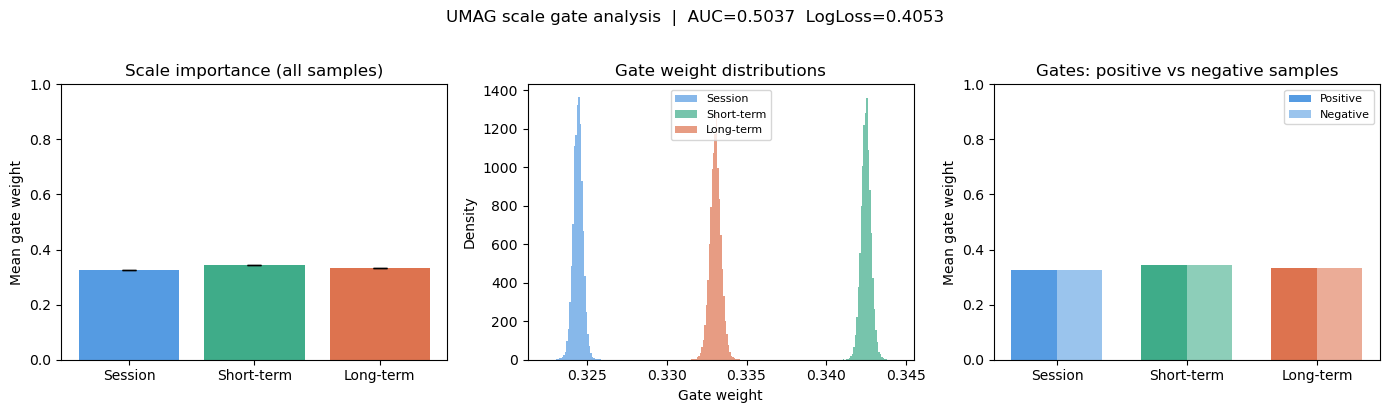


Saved: umag_metrics.csv, umag_gate_analysis.png


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Evaluation + Scale Gate Analysis
#
# This is what makes UMAG academically valuable for your capstone:
# The gate weights tell you QUANTITATIVELY how much each temporal
# scale contributed to predictions — directly answering RQ2.
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import roc_auc_score, log_loss
import numpy as np

model.eval()

all_preds   = []
all_labels  = []
all_gates   = []   # shape: (N, 3) — one gate weight per scale per sample

EVAL_ROWS   = 50_000   # cap evaluation for speed

eval_dataset = UMAGStreamingDataset(
    DATASET_PATH,
    {**CFG, "max_total_rows": EVAL_ROWS, "shuffle_files": False},
    user_history,
    epoch=99,
)
eval_loader = DataLoader(eval_dataset, batch_size=None, num_workers=0)

print(f"Evaluating on up to {EVAL_ROWS:,} samples ...")

with torch.no_grad():
    for user_idx, item_idx, sess_seq, short_seq, long_seq, y in tqdm(eval_loader):

        user_idx  = user_idx.to(device)
        item_idx  = item_idx.to(device)
        sess_seq  = sess_seq.to(device)
        short_seq = short_seq.to(device)
        long_seq  = long_seq.to(device)

        pred, gates, _, _, _ = model(
            user_idx, item_idx, sess_seq, short_seq, long_seq,
            return_weights=True
        )

        all_preds.append(pred.cpu().numpy())
        all_labels.append(y.numpy())
        all_gates.append(gates.cpu().numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_gates  = np.concatenate(all_gates)   # (N, 3)

# ── Core metrics ──
auc     = roc_auc_score(all_labels, all_preds)
logloss = log_loss(all_labels, all_preds)

print("\n" + "=" * 55)
print("UMAG EVALUATION RESULTS")
print("=" * 55)
print(f"  AUC-ROC   : {auc:.4f}")
print(f"  Log-loss  : {logloss:.4f}")
print(f"  Samples   : {len(all_labels):,}")
print(f"  Pos rate  : {all_labels.mean():.3f}")

# ── Scale gate analysis — answers RQ2 ──
# Mean gate weight per scale across all predictions
gate_means = all_gates.mean(axis=0)
gate_stds  = all_gates.std(axis=0)

print("\n" + "=" * 55)
print("SCALE GATE WEIGHTS — answers RQ2")
print("(How much does each temporal scale contribute?)")
print("=" * 55)
print(f"  Session  (last {CFG['session_window']} items)  : "
      f"{gate_means[0]:.4f} ± {gate_stds[0]:.4f}")
print(f"  Short    (last {CFG['short_window']} items)    : "
      f"{gate_means[1]:.4f} ± {gate_stds[1]:.4f}")
print(f"  Long     (all older items)  : "
      f"{gate_means[2]:.4f} ± {gate_stds[2]:.4f}")

dominant = ["Session", "Short-term", "Long-term"][np.argmax(gate_means)]
print(f"\n  Dominant scale: {dominant}")
print("  → Use this finding directly in your RQ2 discussion.")

# ── Gate weights by positive vs negative samples ──
pos_mask = all_labels == 1.0
neg_mask = all_labels == 0.0

print("\n  Gate weights — POSITIVE samples (actual interactions):")
pos_gates = all_gates[pos_mask].mean(axis=0)
print(f"    Session={pos_gates[0]:.4f}  Short={pos_gates[1]:.4f}  Long={pos_gates[2]:.4f}")

print("  Gate weights — NEGATIVE samples (non-interactions):")
neg_gates = all_gates[neg_mask].mean(axis=0)
print(f"    Session={neg_gates[0]:.4f}  Short={neg_gates[1]:.4f}  Long={neg_gates[2]:.4f}")

# ── Visualization ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scale_names = ["Session", "Short-term", "Long-term"]
colors      = ["#378ADD", "#1D9E75", "#D85A30"]

# Plot 1: Mean gate weights bar chart
axes[0].bar(scale_names, gate_means, color=colors, alpha=0.85)
axes[0].errorbar(scale_names, gate_means, yerr=gate_stds,
                 fmt="none", color="black", capsize=5)
axes[0].set_ylabel("Mean gate weight")
axes[0].set_title("Scale importance (all samples)")
axes[0].set_ylim(0, 1)

# Plot 2: Gate weight distributions
for i, (name, color) in enumerate(zip(scale_names, colors)):
    axes[1].hist(all_gates[:, i], bins=40, alpha=0.6,
                 label=name, color=color, density=True)
axes[1].set_xlabel("Gate weight")
axes[1].set_ylabel("Density")
axes[1].set_title("Gate weight distributions")
axes[1].legend(fontsize=8)

# Plot 3: Positive vs negative gate comparison
x     = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, pos_gates, width, label="Positive", alpha=0.85,
            color=colors)
axes[2].bar(x + width/2, neg_gates, width, label="Negative", alpha=0.5,
            color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels(scale_names)
axes[2].set_ylabel("Mean gate weight")
axes[2].set_title("Gates: positive vs negative samples")
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 1)

plt.suptitle(f"UMAG scale gate analysis  |  AUC={auc:.4f}  LogLoss={logloss:.4f}",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("umag_gate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save metrics ──
metrics_df = pd.DataFrame({
    "metric": [
        "auc_roc", "log_loss",
        "gate_session_mean", "gate_short_mean", "gate_long_mean",
        "gate_session_std",  "gate_short_std",  "gate_long_std",
        "dominant_scale",
    ],
    "value": [
        round(auc, 4), round(logloss, 4),
        round(float(gate_means[0]), 4),
        round(float(gate_means[1]), 4),
        round(float(gate_means[2]), 4),
        round(float(gate_stds[0]), 4),
        round(float(gate_stds[1]), 4),
        round(float(gate_stds[2]), 4),
        dominant,
    ]
})
metrics_df.to_csv("umag_metrics.csv", index=False)
print("\nSaved: umag_metrics.csv, umag_gate_analysis.png")


---
## Cell 7 — NFM vs UMAG Comparison

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — NFM vs UMAG Comparison
# Run this AFTER you have trained both models.
# Produces the comparison table for your capstone report.
# ═══════════════════════════════════════════════════════════════

# ── Load NFM checkpoint and evaluate on the same eval set ──

nfm_model = NFMHashed(
    user_buckets = CFG["user_buckets"],
    item_buckets = CFG["item_buckets"],
    embed_dim    = CFG["embed_dim"],
    hidden       = CFG["hidden"],
).to(device)

nfm_ckpt_path = Path("checkpoints_nfm_hash") / "nfm_hashed_final.pt"
nfm_obj       = torch.load(nfm_ckpt_path, map_location="cpu")
nfm_model.load_state_dict(nfm_obj["model"])
nfm_model.eval()
print("NFM loaded from checkpoint.")

# ── Evaluate NFM on same eval subset ──
# NFM only needs (user, item) — ignore sequences
nfm_preds  = []
nfm_labels = []

eval_dataset2 = UMAGStreamingDataset(
    DATASET_PATH,
    {**CFG, "max_total_rows": EVAL_ROWS, "shuffle_files": False},
    user_history,
    epoch=99,
)
eval_loader2 = DataLoader(eval_dataset2, batch_size=None, num_workers=0)

with torch.no_grad():
    for user_idx, item_idx, _, _, _, y in tqdm(eval_loader2, desc="NFM eval"):
        user_idx = user_idx.to(device)
        item_idx = item_idx.to(device)
        pred     = nfm_model(user_idx, item_idx)
        nfm_preds.append(pred.cpu().numpy())
        nfm_labels.append(y.numpy())

nfm_preds  = np.concatenate(nfm_preds)
nfm_labels = np.concatenate(nfm_labels)

nfm_auc  = roc_auc_score(nfm_labels, nfm_preds)
nfm_loss = log_loss(nfm_labels, nfm_preds)

# ── Comparison table ──
print("\n" + "=" * 55)
print("MODEL COMPARISON — same 1% subset, same eval set")
print("=" * 55)
print(f"{'Model':<20} {'AUC-ROC':>10} {'Log-loss':>10} {'Params':>12}")
print("-" * 55)

nfm_params  = sum(p.numel() for p in nfm_model.parameters())
umag_params = sum(p.numel() for p in model.parameters())

print(f"{'NFM (baseline)':<20} {nfm_auc:>10.4f} {nfm_loss:>10.4f} {nfm_params:>12,}")
print(f"{'UMAG':<20} {auc:>10.4f} {logloss:>10.4f} {umag_params:>12,}")

delta_auc  = auc - nfm_auc
delta_loss = logloss - nfm_loss
print(f"\n  UMAG vs NFM:")
print(f"    ΔAUC      = {delta_auc:+.4f}  {'↑ better' if delta_auc > 0 else '↓ worse'}")
print(f"    ΔLog-loss = {delta_loss:+.4f}  {'↓ better' if delta_loss < 0 else '↑ worse'}")

# ── Save comparison ──
comparison_df = pd.DataFrame({
    "model":     ["NFM", "UMAG"],
    "auc_roc":   [round(nfm_auc,  4), round(auc,     4)],
    "log_loss":  [round(nfm_loss, 4), round(logloss,  4)],
    "n_params":  [nfm_params,          umag_params],
    "eval_rows": [len(nfm_labels),     len(all_labels)],
})
comparison_df.to_csv("nfm_vs_umag_comparison.csv", index=False)
print("\nSaved: nfm_vs_umag_comparison.csv")

# ── Bar chart ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

models = ["NFM", "UMAG"]
aucs   = [nfm_auc, auc]
losses = [nfm_loss, logloss]
bar_colors = ["#888780", "#378ADD"]

bars1 = ax1.bar(models, aucs, color=bar_colors, alpha=0.85)
ax1.set_ylim(min(aucs) - 0.02, max(aucs) + 0.02)
ax1.set_ylabel("AUC-ROC")
ax1.set_title("AUC-ROC comparison")
for bar, val in zip(bars1, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)

bars2 = ax2.bar(models, losses, color=bar_colors, alpha=0.85)
ax2.set_ylim(min(losses) - 0.02, max(losses) + 0.02)
ax2.set_ylabel("Log-loss (lower is better)")
ax2.set_title("Log-loss comparison")
for bar, val in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("NFM vs UMAG — 1% dataset subset", y=1.02)
plt.tight_layout()
plt.savefig("nfm_vs_umag_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


NameError: name 'NFMHashed' is not defined